In [27]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [28]:
from src.dataset import PropertyDataset
from src.model import ImageEncoder
import torch

tabular_cols = [
    "bedrooms", "bathrooms", "sqft_living",
    "sqft_lot", "grade", "lat", "long"
]

dataset = PropertyDataset(
    csv_path="../data/raw/train.csv",
    image_dir="../data/images",
    tabular_cols=tabular_cols,
    target_col="price"
)

image, tabular, target = dataset[0]

print(image.shape)
print(tabular.shape)
print(tabular)
print(target)

model = ImageEncoder()
embedding = model(image.unsqueeze(0))

print(embedding.shape)

[INFO] Dataset size after image filtering: 10
torch.Size([3, 224, 224])
torch.Size([7])
tensor([ 4.0000e+00,  2.2500e+00,  1.8100e+03,  9.2400e+03,  7.0000e+00,
         4.7436e+01, -1.2219e+02])
tensor(12.5011)
torch.Size([1, 512])


In [29]:
import sys, os
sys.path.append(os.path.abspath(".."))

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, r2_score

In [30]:
from torch.utils.data import random_split

dataset = PropertyDataset(
    csv_path="../data/raw/train.csv",
    image_dir="../data/images",
    tabular_cols=tabular_cols,
    target_col="price"
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size]
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

[INFO] Dataset size after image filtering: 10


In [31]:
from src.model import MultimodalRegressor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultimodalRegressor(tabular_dim=len(tabular_cols)).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [32]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for images, tabular, targets in loader:
        images = images.to(device)
        tabular = tabular.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        preds = model(images, tabular)
        loss = criterion(preds, targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [33]:
for epoch in range(20):
    loss = train_one_epoch(model, train_loader)
    print(f"Epoch {epoch+1} | MSE Loss: {loss:.4f}")

Epoch 1 | MSE Loss: 1597.2382
Epoch 2 | MSE Loss: 1116.1626
Epoch 3 | MSE Loss: 728.6318
Epoch 4 | MSE Loss: 433.1689
Epoch 5 | MSE Loss: 228.7749
Epoch 6 | MSE Loss: 113.5066
Epoch 7 | MSE Loss: 84.4928
Epoch 8 | MSE Loss: 105.6775
Epoch 9 | MSE Loss: 129.3846
Epoch 10 | MSE Loss: 136.4784
Epoch 11 | MSE Loss: 125.5028
Epoch 12 | MSE Loss: 102.6113
Epoch 13 | MSE Loss: 77.0276
Epoch 14 | MSE Loss: 57.8763
Epoch 15 | MSE Loss: 53.9045
Epoch 16 | MSE Loss: 59.8061
Epoch 17 | MSE Loss: 63.6637
Epoch 18 | MSE Loss: 61.0433
Epoch 19 | MSE Loss: 52.3624
Epoch 20 | MSE Loss: 40.9910


In [34]:
import numpy as np
model.eval()

y_true_log = []
y_pred_log = []

with torch.no_grad():
    for images, tabular, targets in val_loader:
        images = images.to(device)
        tabular = tabular.to(device)

        preds = model(images, tabular)

        y_true_log.extend(targets.cpu().numpy())
        y_pred_log.extend(preds.cpu().numpy())

y_true_log = np.array(y_true_log)
y_pred_log = np.array(y_pred_log)

from sklearn.metrics import mean_squared_error, r2_score

mse_log = mean_squared_error(y_true_log, y_pred_log)
rmse_log = np.sqrt(mse_log)
r2_log = r2_score(y_true_log, y_pred_log)

print("Log-RMSE:", rmse_log)
print("Log-R²:", r2_log)

Log-RMSE: 5.96115827839016
Log-R²: -288.8702697753906


In [35]:
gradients = None
activations = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer = model.image_encoder.features[-1]
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

In [36]:
for param in model.image_encoder.features.parameters():
    param.requires_grad = True

In [ ]:
def generate_gradcam(model, image, tabular):
    model.eval()

    image = image.unsqueeze(0).to(device)
    tabular = tabular.unsqueeze(0).to(device)

    output = model(image, tabular, enable_gradcam=True)

    model.zero_grad()
    output.backward()

    gradients = model.image_encoder.feature_maps.grad
    activations = model.image_encoder.feature_maps

    weights = gradients.mean(dim=(2, 3), keepdim=True)
    cam = (weights * activations).sum(dim=1)

    cam = cam.squeeze().detach().cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)

    return cam


In [38]:
def overlay_gradcam(image, cam):
    """
    Overlays Grad-CAM heatmap on original image
    """
    # Convert image to numpy
    img = image.permute(1, 2, 0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    # Resize CAM to image size
    cam_resized = cv2.resize(cam, (224, 224))
    cam_resized = (cam_resized - cam_resized.min()) / (cam_resized.max() - cam_resized.min())

    # Apply colormap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = heatmap / 255.0

    # Overlay
    overlay = 0.6 * img + 0.4 * heatmap
    overlay = np.clip(overlay, 0, 1)

    return overlay


/Users/vedparikh/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


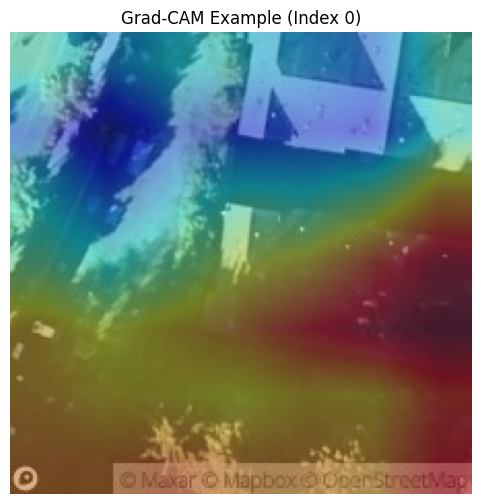

/Users/vedparikh/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


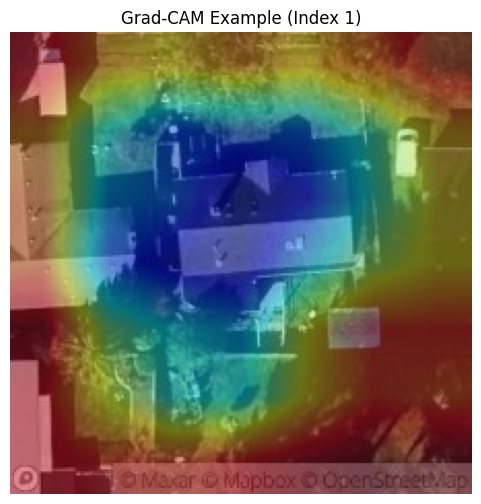

In [39]:
indices = range(min(3, len(val_dataset)))

for i in indices:
    image, tabular, target = val_dataset[i]

    cam = generate_gradcam(model, image, tabular)
    overlay = overlay_gradcam(image, cam)

    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.title(f"Grad-CAM Example (Index {i})")
    plt.axis("off")
    plt.show()


In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

train_df = pd.read_csv("../data/raw/train.csv")

X_train = train_df[tabular_cols]
y_train = train_df["price"]

tabular_model = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

tabular_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [41]:
from PIL import Image

model.eval()

test_df = pd.read_csv("../data/raw/test.csv")

for col in tabular_cols:
    test_df[col] = pd.to_numeric(test_df[col], errors="coerce")

test_df[tabular_cols] = test_df[tabular_cols].fillna(0.0)

final_predictions = []

for idx, row in test_df.iterrows():
    img_path = f"../data/images/{idx}.png"

    tabular_np = (
        row[tabular_cols]
        .astype(float)
        .values
        .reshape(1, -1)
    )
    tabular_tensor = torch.tensor(tabular_np, dtype=torch.float32).to(device)

    tabular_df = pd.DataFrame(
        [row[tabular_cols].astype(float).values],
        columns=tabular_cols
    )

    if os.path.exists(img_path):
        image = Image.open(img_path).convert("RGB")
        image = dataset.transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            pred_log = model(image, tabular_tensor).item()

        if pred_log < 0.1:
            pred = tabular_model.predict(tabular_df)[0]
        else:
            pred_log = np.clip(pred_log, 0, 15)
            pred = np.expm1(pred_log)

    else:
        pred = tabular_model.predict(tabular_df)[0]

    final_predictions.append(pred)

submission = pd.DataFrame({
    "id": test_df.index,
    "predicted_price": final_predictions
})

submission.to_csv("../outputs/24112080_final.csv", index=False)

print(submission.head(10))
print(submission.describe())


   id  predicted_price
0   0     2.692417e+03
1   1     2.042386e+04
2   2     2.446505e+05
3   3     2.029281e+06
4   4     5.395186e+03
5   5     1.902449e+03
6   6     7.832156e+03
7   7     4.942676e+02
8   8     5.693102e+02
9   9     5.180872e+01
                id  predicted_price
count  5404.000000     5.404000e+03
mean   2701.500000     5.456796e+05
std    1560.144758     3.573256e+05
min       0.000000     5.180872e+01
25%    1350.750000     3.283676e+05
50%    2701.500000     4.582051e+05
75%    4052.250000     6.484334e+05
max    5403.000000     5.950986e+06


In [42]:
submission = pd.DataFrame({
    "id": test_df.index,
    "predicted_price": final_predictions
})

submission.to_csv("24112080_final.csv", index=False)

submission.head()

,id,predicted_price
0,0,2.692417e+03
1,1,2.042386e+04
2,2,2.446505e+05
3,3,2.029281e+06
4,4,5.395186e+03


In [43]:
import pandas as pd

train_df = pd.read_csv("../data/raw/train.csv")

In [44]:
X = train_df[tabular_cols]
y = train_df["price"]

for col in tabular_cols:
    X[col] = pd.to_numeric(X[col], errors="coerce")

X = X.fillna(0.0)

/var/folders/hv/m560wcmn6qg0qwwmxw5lsyzc0000gn/T/ipykernel_3661/2842498340.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = pd.to_numeric(X[col], errors="coerce")


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

tabular_model = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

tabular_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [47]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

y_pred_tab = tabular_model.predict(X_val)
mse = mean_squared_error(y_val, y_pred_tab)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred_tab)

print("Tabular-only RMSE:", rmse)
print("Tabular-only R²:", r2)

Tabular-only RMSE: 145383.87484519975
Tabular-only R²: 0.831566617764266
